In [2]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

### Building R and X matrix for calculating Voltages later.

In [3]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [4]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [5]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [6]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [7]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [8]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [9]:
bus_load_kw = bus_load / 0.25 # Converting to KW : P = E/t



# --- Step 1: scale loads for voltage feasibility FIRST ---
peak_load_kw_raw = bus_load_kw.sum(axis=1).max()
S_base_temp = peak_load_kw_raw # temporary maximum power as base to calculate per-unit loads for voltage constraint evaluation.
bus_load_pu_temp = bus_load_kw / S_base_temp

pf = np.full(bus_load_pu_temp.shape[1], 0.9)
eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)
Z = R + X @ np.diag(eta_bus)

v_base = 1.0 - (bus_load_pu_temp.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Raw peak load (kW):", peak_load_kw_raw)
print("Minimum baseline voltage before scaling:", vmin_actual)

# scaling all loads down so minimum voltage becomes 0.95 p.u.
scale_voltage = (1.0 - 0.95) / (1.0 - vmin_actual)
bus_load_kw_scaled = bus_load_kw * scale_voltage


# Step 2: setting transformer capacity AFTER voltage scaling 
peak_load_kw_scaled = bus_load_kw_scaled.sum(axis=1).max()
S_base = peak_load_kw_scaled
bus_load_pu = bus_load_kw_scaled / S_base  # Converting to per unit

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("\n")
print("Applied voltage scaling factor:", scale_voltage)
print("Peak load after voltage scaling (kW):", peak_load_kw_scaled)
print("Transformer rating S_base (kW):", S_base)
print("Peak load in pu after voltage scaling:", bus_load_pu.sum(axis=1).max())
print("Minimum baseline voltage after scaling:", vmin_actual)


# --- Step 3: further scale loads down to create headroom ---
bus_load_pu = 0.9 * bus_load_pu   # this is what we will use for the rest of analysis.
bus_load_kw_final = 0.9 * bus_load_kw_scaled # this is what we will use for the rest of analysis.

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_final = v_base.min()

print("\n")
print("Final peak load after headroom scaling (kW):", bus_load_kw_final.sum(axis=1).max())
print("Transformer rating remains fixed (kW):", S_base)
print("Final peak load in pu:", bus_load_pu.sum(axis=1).max())
print("Minimum voltage after headroom scaling:", vmin_final)
print("Available headroom at peak (pu):", 1.0 - bus_load_pu.sum(axis=1).max())
print("Available headroom at peak (kW):", S_base - bus_load_kw_final.sum(axis=1).max())



Raw peak load (kW): 464.5039999999999
Minimum baseline voltage before scaling: 0.9463326002665228


Applied voltage scaling factor: 0.9316642924440125
Peak load after voltage scaling (kW): 432.76179049741353
Transformer rating S_base (kW): 432.76179049741353
Peak load in pu after voltage scaling: 1.0
Minimum baseline voltage after scaling: 0.9463326002665228


Final peak load after headroom scaling (kW): 389.4856114476723
Transformer rating remains fixed (kW): 432.76179049741353
Final peak load in pu: 0.8999999999999999
Minimum voltage after headroom scaling: 0.9516993402398705
Available headroom at peak (pu): 0.10000000000000009
Available headroom at peak (kW): 43.276179049741245


### EV Charging Dataset (Norway)

In [10]:
ev_df = pd.read_csv('EV/dataset_3a_aggregated.csv', sep=';')
ev_df = ev_df[['date_from', 'Synthetic_7_2kW']]

ev_df['Synthetic_7_2kW'] = (
    ev_df['Synthetic_7_2kW']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

ev_df['date_from'] = pd.to_datetime(ev_df['date_from'], dayfirst=True)
ev_df = ev_df.set_index('date_from').sort_index()

ev_df.drop_duplicates(inplace=True)

# Resampling to 15-minutes interval
ev_df = ev_df.resample('15T').interpolate(method='linear')
ev_df =  ev_df.loc['2019-01-01 00:15:00':'2020-01-01 00:00:00']
ev_df.index = ev_df.index - pd.DateOffset(years=12)

C:\Users\gcsar\AppData\Local\Temp\ipykernel_12468\105924172.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


### Base and EV data visualization

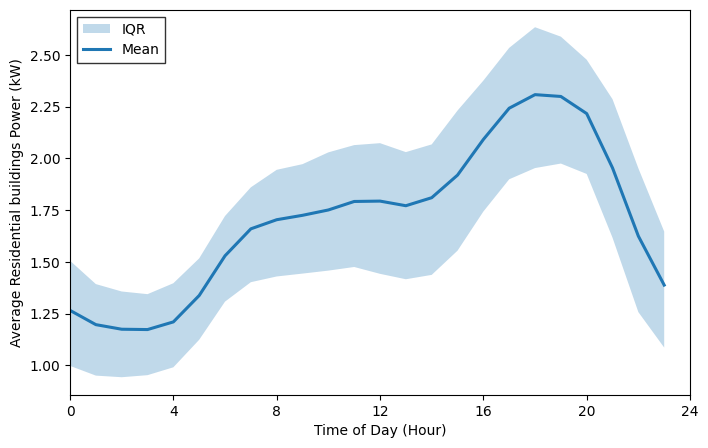

In [11]:
base_load = bus_load_kw_final.mean(axis=1)

def hourly_mean_iqr(series):
    df = pd.DataFrame({"value": series})
    df["hour"] = df.index.hour

    stats = df.groupby("hour")["value"].agg([
        ("q25", lambda x: np.percentile(x, 25)),
        ("mean", "mean"),
        ("q75", lambda x: np.percentile(x, 75)),
    ])
    return stats

res_stats = hourly_mean_iqr(base_load)

# Residential power plot
plt.figure(figsize=(8, 5))
h = res_stats.index.to_numpy()
m = res_stats["mean"].to_numpy()
q25 = res_stats["q25"].to_numpy()
q75 = res_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Average Residential buildings Power (kW)")
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


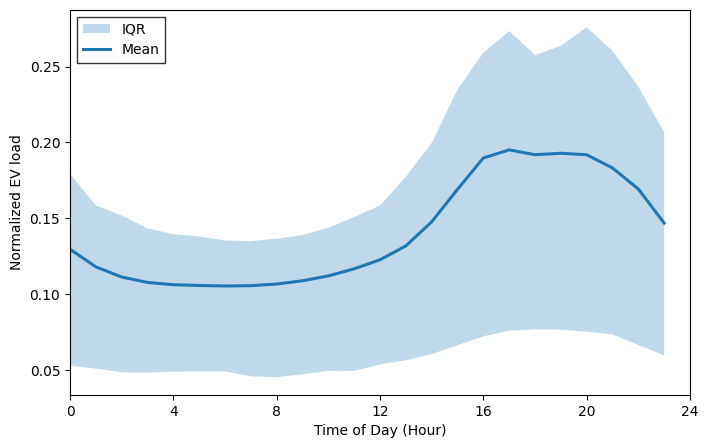

In [12]:
ev_df_plot = ev_df.copy()
ev_df_plot['Synthetic_7_2kW'] = ev_df_plot['Synthetic_7_2kW']/ev_df_plot['Synthetic_7_2kW'].max()

ev_stats = hourly_mean_iqr(ev_df_plot['Synthetic_7_2kW']) 

# Residential power plot
plt.figure(figsize=(8, 5))
h = ev_stats.index.to_numpy()
m = ev_stats["mean"].to_numpy()
q25 = ev_stats["q25"].to_numpy()
q75 = ev_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Normalized EV load")
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


### Hosting Capacity

In [13]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - (Z @ ell)
        denominator = Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)
        # C_res[t] = headroom_tx

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

In [14]:
# Normalized flexible load profile (EV charing profile in this case)

ev_profile = ev_df["Synthetic_7_2kW"].copy()
ev_profile = ev_profile.reindex(bus_load_pu.index)

# normalize
lhat = ev_profile.to_numpy(dtype=float)
lhat = lhat / lhat.max()

print("Length of lhat:", len(lhat))
print("Min/Max of lhat:", lhat.min(), lhat.max())

# or comment out all above and use the following dummy lhat for testing
# lhat = np.ones(len(bus_load_pu)) # Normalized load

Length of lhat: 35040
Min/Max of lhat: 0.0001314233144959916 1.0


### Experiments with interventions

In [19]:
def optimization(
    C_res,
    lhat,
    alpha=0.95,   # CVaR confidence level, not intervention fraction
    mu=0.10,      # tail curtailment cap as fraction of C
    solver="GUROBI",
    verbose=True,
):
    T = len(C_res)

    C = cp.Variable(nonneg=True, name="C")
    u = cp.Variable(T, nonneg=True, name="u")
    eta = cp.Variable(name="eta")
    s = cp.Variable(T, nonneg=True, name="s")

    constraints = [
        C * lhat - u <= C_res,     # enough curtailment to avoid violation
        s >= u - mu * C * lhat - eta,     # CVaR epigraph
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0
    ]

    prob = cp.Problem(cp.Maximize(C), constraints)
    prob.solve(solver=solver, verbose=verbose)

    result = {
        "status": prob.status,
        "objective": None if prob.value is None else float(prob.value),
        "C": None if C.value is None else float(C.value),
        "eta": None if eta.value is None else float(eta.value),
        "u": None if u.value is None else np.asarray(u.value).flatten(),
    }
    return result

In [20]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)


alpha = 0.95
epsilon = 0.0

# Curtailment budget parameters
dt = 0.25      # 15-minute intervals = 0.25 hour
mu = 0.1       # max 10% curtailment per timestamp

res = optimization(
    C_res=C_res,
    lhat=lhat,
    alpha=alpha,
    mu=mu,
    solver="CLARABEL",
    verbose=True,
)

print("Status:", res["status"])
print("Optimal C:", res["C"])
print("Optimal C in kW:", None if res["C"] is None else res["C"] * S_base)
print("eta:", res["eta"])

(CVXPY) Mar 27 06:08:12 PM: Your problem has 70082 variables, 70081 constraints, and 0 parameters.
(CVXPY) Mar 27 06:08:12 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 27 06:08:12 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 27 06:08:12 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 27 06:08:12 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 27 06:08:12 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Mar 27 06:08:12 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Mar 27 06:08:12 PM: Applying reduction FlipObjective
(CVXPY) Mar 27 06:08:12 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 27 06:08:12 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 27 06:08:12 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 27 06:08:12 P

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 70082
  constrain

(CVXPY) Mar 27 06:08:15 PM: Problem status: optimal
(CVXPY) Mar 27 06:08:15 PM: Optimal value: 5.389e-01
(CVXPY) Mar 27 06:08:15 PM: Compilation took 1.289e-01 seconds
(CVXPY) Mar 27 06:08:15 PM: Solver (including time spent in interface) took 2.513e+00 seconds


 57  -5.3886e-01  -5.3891e-01  5.66e-05  2.22e-08  1.22e-06  4.29e-10  7.66e-08  8.61e-01  
 58  -5.3886e-01  -5.3886e-01  1.82e-06  7.17e-10  3.94e-08  1.38e-11  2.47e-09  9.90e-01  
 59  -5.3886e-01  -5.3886e-01  1.89e-08  7.42e-12  4.08e-10  1.43e-13  2.56e-11  9.90e-01  
 60  -5.3886e-01  -5.3886e-01  1.92e-10  7.55e-14  4.13e-12  1.45e-15  2.59e-13  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 2.4729352s
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Optimal C: 0.5388623782796447
Optimal C in kW: 233.19904765599358
eta: -0.0010746022079874044


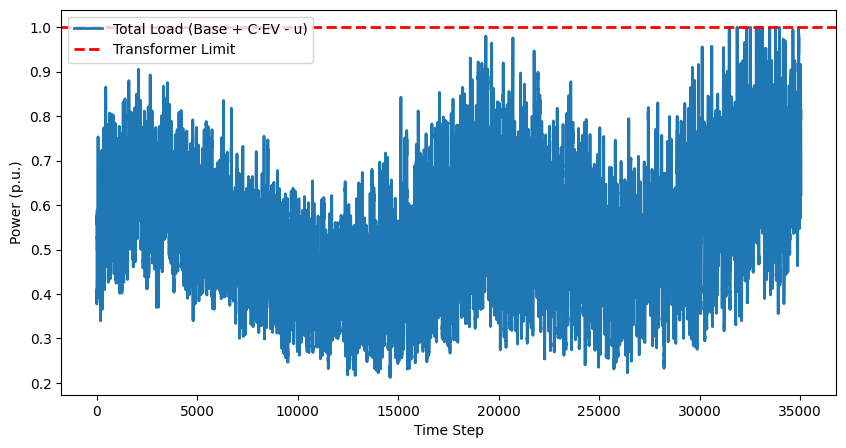

In [21]:
t = np.arange(T)
total_load = bus_load_pu.sum(axis=1) + res['C'] * lhat - res['u']

limit = 1.0
plt.figure(figsize=(10, 5))
plt.plot(t, total_load, linewidth=2, label="Total Load (Base + C·EV - u)")
plt.axhline(limit, color='red', linestyle='--', linewidth=2, label="Transformer Limit")

plt.xlabel("Time Step")
plt.ylabel("Power (p.u.)")
plt.legend()
plt.show()

Text(0, 0.5, 'Curtailment (p.u.)')

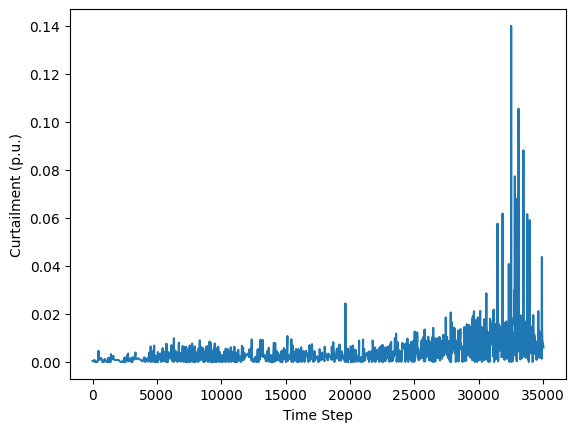

In [22]:
plt.plot(t, res['u'], label='Curtailment u')
plt.xlabel("Time Step")
plt.ylabel("Curtailment (p.u.)")

Violation occurs : 40


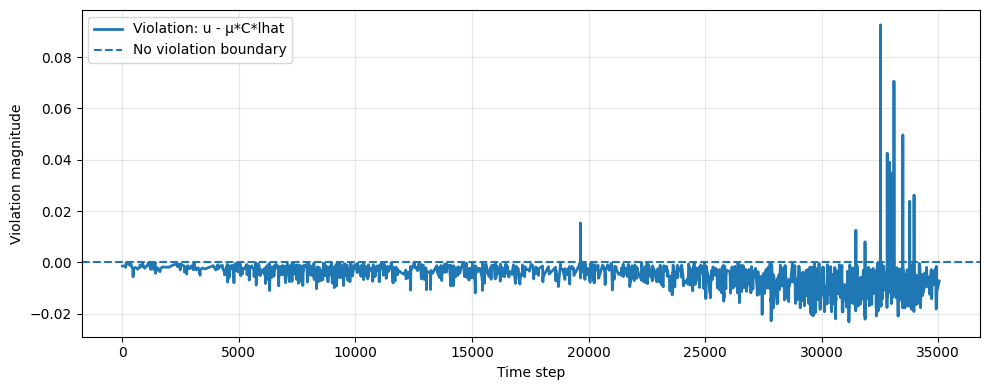

In [28]:
allowed_curt = 0.10 * res["C"] * lhat
violation = res["u"] - allowed_curt

violation_idx = np.where(violation > 0)[0]
print ("Violation occurs :", len(violation_idx))

T = len(violation)

plt.figure(figsize=(10, 4))
plt.plot(range(T), violation, linewidth=2, label="Violation: u - μ*C*lhat")
plt.axhline(0, linestyle="--", label="No violation boundary")


plt.xlabel("Time step")
plt.ylabel("Violation magnitude")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()